# Workstream 4: Stress Test & Mitigation Scenario

**Target:** Total GHG excl LULUCF (Mt CO₂e)
<br> **Countries:** Thailand (THA) & Philippines (PHL)
<br> **Horizon:** Project from 2024 baseline to 2030
<br> **Scenarios:** Business-as-usual (BAU) vs NDC-aligned mitigation
<br> **Model:** Fixed-effects data regression coefficients from WS2

**Output:** BAU and mitigation GHG projections, decomposition by lever, sensitivity analysis, NDC cross-check

| Step | What | Output |
|------|------|--------|
| **1 Data Preparation** | (A) Load WS2 exports; <br>(B) Load data, filter THA & PHL; <br>(C) Verify FE formula; compute 2024 residual anchor; <br>(D) Estimate coal overlay coefficient (FWL) | `Coefs`, `Country_Means`, `Data`, `Residual_Ln`, `Beta_Coal` |
| **2 BAU Projections** | (A) Fit linear trends (2017–2024 excl COVID); <br>(B) Extrapolate predictors to 2030; <br>(C) Apply FE formula → BAU path | `Bau` dataframe |
| **3 NDC Mitigation Scenario** | (A) Define mitigation assumptions; <br>(B) Override 4 levers (RE, Energy, Forest, Coal); <br>(C) Apply FE formula → mitigation path; <br>(D) Compare BAU vs mitigation | `Mit` dataframe, summary table, line chart |
| **4 Decomposition & Sensitivity** | (A) Isolate each lever's contribution; <br>(B) ±20% sensitivity per assumption | `Decomp`, `Sensitivity` tables, stacked bar, tornado chart |
| **4.5 Delayed-Transition Stress** | (A) Define downside shocks vs BAU; <br>(B) Build stress predictor table; <br>(C) Apply FE formula → stress path; <br>(D) Three-scenario summary; <br>(E) Fan chart; <br>(F) Stylised insured-loss layer | `Stress` dataframe, `Stress_Summary`, fan chart |
| **5 NDC Cross-Check & Implications** | (A) Compare to official NDC targets; <br>(B) Financial implications (TCFD / IFRS S2) | Summary print output |
| **6 Export** | Save projections, summaries, charts | CSVs + PNGs |

## Working Directory
Set `Drive_Path` to your local project folder (only thing to change).
<br> All other paths derive from it.

In [1]:
from pathlib import Path
import os

## Only change this line: 
Drive_Path = Path.home() / "Desktop/MASAHKT2026/Model"

In [2]:
# Define subdirectories
Data_Path = Drive_Path / "Data"
Code_Path = Drive_Path / "Code"
Output_Path = Drive_Path / "Output"
Output_WS1 = Output_Path / "Output_WS1"
Output_WS2 = Output_Path / "Output_WS2"
Output_WS3 = Output_Path / "Output_WS3"
Output_WS4 = Output_Path / "Output_WS4"

# Define input file names
Data_Filename = 'WS1_Data_Imputed.csv'

# Source annotations (chart footnotes)
WDI_Source = 'Source: World Bank WDI (Wide Format), accessed 2026-04-26'
Model_Source = 'Source: Projections using FE coefficients from WS2'

# Create directories if they don't exist
for p in [Data_Path, Code_Path, Output_Path, Output_WS4]:
    p.mkdir(parents=True, exist_ok=True)

## Setup
* Import libraries
* Set plotting style and colour codes
* Define constants: target, predictors, log-transform list, country mapping

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Plot styling 
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 180,
    'savefig.bbox': 'tight',
    'figure.facecolor': 'white',
})

Colors = {'Thailand': '#E63946', 'Philippines': '#1D3557'}
Colors_Light = {'Thailand': '#FFCDD2', 'Philippines': '#B3CDE3'}
Scenario_Colors = {'BAU': '#7f8c8d', 'Mitigation': '#27ae60'}

# Country mapping
Country_Map = {'THA': 'Thailand', 'PHL': 'Philippines'}
Focus_Countries = ['THA', 'PHL']

# --- Column name conventions ---
# RAW columns: 7 predictors, EXACTLY matching WS2 (no coal in this list)
Raw_Cols = ['Population', 'GDP_Per_Capita_PPP', 'Energy_Per_Capita',
            'Renewable_%', 'Urban_%', 'Forest_%', 'Agri_VA_%']

# Variables that are log-transformed before entering the model
Log_Vars = ['Population', 'GDP_Per_Capita_PPP', 'Energy_Per_Capita']

# MODEL columns: what WS2 actually uses (ln_ prefix for logged variables)
# These match the Variable column in WS2_Coefficients.csv and
# the column headers in WS2_Country_Means_X.csv
Model_Cols = [f'ln_{col}' if col in Log_Vars else col for col in Raw_Cols]

# Coal_Elec_% is the OVERLAY variable. Not part of WS2's 7 predictors.
# Estimated separately in Step 1(D) and applied multiplicatively to scenario
# predictions (BAU coal stays at baseline -> overlay has no effect at BAU).
Overlay_Var = 'Coal_Elec_%'


# Predictor display names for charts
Pred_Labels = {
    'Population':         'Population',
    'GDP_Per_Capita_PPP': 'GDP Per Capita (PPP)',
    'Energy_Per_Capita':  'Energy Use Per Capita',
    'Renewable_%':        'Renewable Energy (%)',
    'Urban_%':            'Urban Pop (%)',
    'Forest_%':           'Forest Area (%)',
    'Agri_VA_%':          'Agriculture VA (% GDP)',
    'Coal_Elec_%':        'Coal % Electricity',
}

# Projection years
Proj_Years = list(range(2025, 2031))

# Trend fitting window: 2017–2024 excluding COVID years
Trend_Years = [2017, 2018, 2019, 2022, 2023, 2024]

print('Setup complete.')


Setup complete.


## Helper Functions

- **`FE_Predict_Single`** — Predict ln(GHG) using FE model: y_hat = y_bar(train) + B_hat . (X - X_bar(train))
- **`Fit_Trend`** — Fit a linear trend on the non-COVID window and extrapolate to projection years
- **`Raw_To_Model`** — Convert raw predictor dict to model-space array (log where needed)
- **`Predict_Ghg_Mt`** — End-to-end: raw predictor dict to GHG in Mt CO2e
- **`Predict_Ghg_Mt_Adjusted`** — Same as above but adds 2024 ln-scale residual so projections anchor to the actual level, not the model's fitted level

In [4]:

def FE_Predict_Single(x_model, coefs, y_bar, x_bar):
    """Predict ln(GHG) for a single observation using FE formula.
    All inputs must be in MODEL SPACE (already log-transformed where needed).
    y_hat = y_bar(train) + B_hat . (X_model - X_bar_model(train))
    """
    return y_bar + coefs @ (x_model - x_bar)


def Fit_Trend(series, trend_years, proj_years):
    """Fit linear trend on non-COVID years, extrapolate to projection years.
    Operates on RAW (original-scale) data.
    Returns dict: {year: projected_value} for all projection years.
    """
    sub = series[series.index.isin(trend_years)].dropna()
    if len(sub) < 3:
        last_val = series.dropna().iloc[-1]
        return {y: last_val for y in proj_years}

    X = sub.index.values.reshape(-1, 1)
    y = sub.values
    Reg = LinearRegression().fit(X, y)

    return {y_: Reg.predict([[y_]])[0] for y_ in proj_years}


def Raw_To_Model(raw_dict):
    """Convert a dict of {raw_col: raw_value} to a model-space numpy array.
    Log-transforms variables in Log_Vars; leaves percentages as-is.
    Returns array in Model_Cols order.
    """
    row = []
    for col in Raw_Cols:
        val = raw_dict[col]
        if col in Log_Vars:
            row.append(np.log(max(val, 1e-6)))
        else:
            row.append(val)
    return np.array(row)


def Predict_Ghg_Mt(raw_dict, coefs, y_bar, x_bar):
    """End-to-end: raw predictor dict -> GHG in Mt CO2e.
    Handles log transform and FE prediction in one call.
    """
    x_model = Raw_To_Model(raw_dict)
    ln_ghg = FE_Predict_Single(x_model, coefs, y_bar, x_bar)
    return np.exp(ln_ghg)

def Predict_Ghg_Mt_Adjusted(raw_dict, coefs, y_bar, x_bar, residual_ln):
    """Same as Predict_Ghg_Mt but adds a level adjustment (ln-scale residual)
    so projections anchor to the 2024 actual, not the model's fitted level.
    """
    x_model = Raw_To_Model(raw_dict)
    ln_ghg = FE_Predict_Single(x_model, coefs, y_bar, x_bar)
    return np.exp(ln_ghg + residual_ln)


def Predict_Ghg_With_Coal(raw_dict, coal_value, coefs, y_bar, x_bar,
                          residual_ln, beta_coal, coal_baseline):
    """Adjusted prediction with COAL OVERLAY applied multiplicatively.

    GHG_with_coal = GHG_WS2 * exp(beta_coal * (coal_value - coal_baseline))

    At BAU (coal_value == coal_baseline) the overlay = 1, so predictions
    match WS2 exactly. Only mitigation/stress (where coal differs from
    baseline) diverge.
    """
    x_model = Raw_To_Model(raw_dict)
    ln_ghg = FE_Predict_Single(x_model, coefs, y_bar, x_bar)
    ln_overlay = beta_coal * (coal_value - coal_baseline)
    return np.exp(ln_ghg + residual_ln + ln_overlay)


print('Helpers ready.')


Helpers ready.


## Step 1: Data Preparation

### Step 1(A) Load WS2 Exports
Load the coefficient table and country means from WS2.
* WS2 stores coefficients and country means in **model space** (ln_ prefix for logged variables).
* We extract the coefficient vector in `Model_Cols` order.

<br> These are the inputs for the FE prediction formula: 
> ŷᵢₜ = ȳᵢ(train) + β̂ · (Xᵢₜ − X̄ᵢ(train))

In [5]:
# (A) Load WS2 exports
Coef_Df = pd.read_csv(Data_Path / 'WS2_Coefficients.csv')
Country_Means_y = pd.read_csv(Data_Path / 'WS2_Country_Means_Y.csv',
                              index_col=0, header=0).squeeze()
Country_Means_X = pd.read_csv(Data_Path / 'WS2_Country_Means_X.csv',
                              index_col=0)

# Extract coefficient vector in Model_Cols order
Coef_Map = dict(zip(Coef_Df['Variable'], Coef_Df['Coefficient']))
Coefs = np.array([Coef_Map[c] for c in Model_Cols])

# Country means X columns should match Model_Cols
assert list(Country_Means_X.columns) == Model_Cols, (
    f'Column mismatch:\n  Expected: {Model_Cols}\n  Got:      {list(Country_Means_X.columns)}')

print('=' * 72)
print('   STEP 1(A) WS2 EXPORTS LOADED')
print('=' * 72)
print(f'Coefficients loaded: {len(Coefs)} predictors')
print(f'Country means: {len(Country_Means_y)} countries')
print()
print('Coefficient vector (Model_Cols order):')
for mcol, rcol, coef in zip(Model_Cols, Raw_Cols, Coefs):
    print(f'  {mcol:<30s} ({rcol:<25s}) {coef:+.4f}')
print()
print('Focus country means (y_bar from training):')
for code in Focus_Countries:
    print(f'  {code}: y_bar = {Country_Means_y[code]:.4f}  '
          f'(approx {np.exp(Country_Means_y[code]):.1f} Mt CO2e)')

   STEP 1(A) WS2 EXPORTS LOADED
Coefficients loaded: 7 predictors
Country means: 130 countries

Coefficient vector (Model_Cols order):
  ln_Population                  (Population               ) +0.6934
  ln_GDP_Per_Capita_PPP          (GDP_Per_Capita_PPP       ) +0.2275
  ln_Energy_Per_Capita           (Energy_Per_Capita        ) +0.4547
  Renewable_%                    (Renewable_%              ) -0.0105
  Urban_%                        (Urban_%                  ) -0.0045
  Forest_%                       (Forest_%                 ) -0.0012
  Agri_VA_%                      (Agri_VA_%                ) +0.0017

Focus country means (y_bar from training):
  THA: y_bar = 5.8677  (approx 353.4 Mt CO2e)
  PHL: y_bar = 5.0731  (approx 159.7 Mt CO2e)


### Step 1(B) Load Data Data
Load the imputed data from WS1 and filter to Thailand and Philippines.

In [6]:
# (B) Load WS1 data, filter to focus countries
Data = pd.read_csv(Data_Path / Data_Filename)

# If Coal_Elec_% is not in the WS1 data, pull it from raw WDI and merge
if 'Coal_Elec_%' not in Data.columns:
    print('Coal_Elec_% not found in WS1 data - pulling from raw WDI...')
    Raw_WDI_Filename = 'WB_WDI_WIDEF.csv'
    raw_wdi_path = Data_Path / Raw_WDI_Filename
    if not raw_wdi_path.exists():
        raise FileNotFoundError(
            f"Need raw WDI file at: {raw_wdi_path}\n"
            f"Place WB_WDI_WIDEF.csv in your Data folder, or re-run WS1 to "
            f"include Coal_Elec_% (WB_WDI_EG_ELC_COAL_ZS) in the imputed data."
        )
    year_cols_str = [str(y) for y in range(2000, 2025)]
    usecols = ['REF_AREA', 'INDICATOR'] + year_cols_str
    coal_chunks = []
    for chunk in pd.read_csv(raw_wdi_path, usecols=usecols,
                             low_memory=False, chunksize=50_000):
        keep = chunk[chunk['INDICATOR'] == 'WB_WDI_EG_ELC_COAL_ZS']
        if len(keep) > 0:
            coal_chunks.append(keep)
    coal_raw = pd.concat(coal_chunks, ignore_index=True)
    coal_long = coal_raw.melt(id_vars=['REF_AREA'], value_vars=year_cols_str,
                              var_name='Year', value_name='Coal_Elec_%')
    coal_long['Year'] = coal_long['Year'].astype(int)
    coal_long = coal_long.rename(columns={'REF_AREA': 'Ref_Area'})
    coal_long = coal_long[coal_long['Ref_Area'].str.len() == 3]
    Data = Data.merge(coal_long, on=['Ref_Area', 'Year'], how='left')
    Data = Data.sort_values(['Ref_Area', 'Year'])
    Data['Coal_Elec_%'] = Data.groupby('Ref_Area')['Coal_Elec_%'].transform(
        lambda s: s.interpolate(limit=2).ffill(limit=2).bfill(limit=2))
    print(f'  Coal_Elec_% coverage: {Data["Coal_Elec_%"].notna().mean()*100:.1f}%')

# Save the FULL data for the coal-overlay estimation step (Step 1D)
Data_Full = Data.copy()

# Restrict to focus countries for the rest of WS4
Data = Data[Data['Ref_Area'].isin(Focus_Countries)].copy()
Data['Country'] = Data['Ref_Area'].map(Country_Map)

# Verify raw columns exist
for col in Raw_Cols + ['Total_GHG', 'Coal_Elec_%']:
    assert col in Data.columns, f'Missing column: {col}'

print('=' * 72)
print('   STEP 1(B) PANEL DATA LOADED')
print('=' * 72)
print(f'Source:    {Data_Filename}')
print(f'Countries: {Data.Ref_Area.unique().tolist()}')
print(f'Years:     {Data.Year.min()} - {Data.Year.max()}')
print(f'Rows:      {len(Data)}')
print()
print('2024 actual values (raw scale):')
for code in Focus_Countries:
    row = Data[(Data.Ref_Area == code) & (Data.Year == 2024)].iloc[0]
    name = Country_Map[code]
    print(f'  {name}:')
    print(f'    Total GHG:      {row["Total_GHG"]:.1f} Mt CO2e')
    print(f'    Renewable %:    {row["Renewable_%"]:.1f}%')
    print(f'    Coal % elec:    {row["Coal_Elec_%"]:.1f}%')
    print(f'    Energy/cap:     {row["Energy_Per_Capita"]:.0f} kg oil eq')
    print(f'    Forest %:       {row["Forest_%"]:.1f}%')


Coal_Elec_% not found in WS1 data - pulling from raw WDI...
  Coal_Elec_% coverage: 100.0%
   STEP 1(B) PANEL DATA LOADED
Source:    WS1_Data_Imputed.csv
Countries: ['PHL', 'THA']
Years:     2000 - 2024
Rows:      50

2024 actual values (raw scale):
  Thailand:
    Total GHG:      422.4 Mt CO2e
    Renewable %:    19.0%
    Coal % elec:    14.6%
    Energy/cap:     1851 kg oil eq
    Forest %:       38.7%
  Philippines:
    Total GHG:      266.6 Mt CO2e
    Renewable %:    28.0%
    Coal % elec:    62.5%
    Energy/cap:     580 kg oil eq
    Forest %:       24.5%


### Step 1(C) Verify FE Prediction Formula
Sanity check: Apply the FE formula to 2024 actual data and compare to WS2's 2024 predictions.
If the numbers match, the formula is correctly reconstructed.

> The key: `Raw_To_Model()` converts raw data values to model space (log where needed),
> then `FE_Predict_Single()` applies B_hat . (X - X_bar) + y_bar in that model space.

In [7]:
# (C) Verify FE formula reproduces WS2 predictions
print('=' * 72)
print('   STEP 1(C): FE FORMULA VERIFICATION')
print('=' * 72)

for code in Focus_Countries:
    row = Data[(Data.Ref_Area == code) & (Data.Year == 2024)].iloc[0]
    y_bar = Country_Means_y[code]
    x_bar = Country_Means_X.loc[code].values

    # Build raw dict -> model space -> predict
    raw_dict = {col: row[col] for col in Raw_Cols}
    ghg_pred = Predict_Ghg_Mt(raw_dict, Coefs, y_bar, x_bar)
    ghg_actual = row['Total_GHG']
    error_pct = (ghg_pred - ghg_actual) / ghg_actual * 100

    name = Country_Map[code]
    print(f'{name}:')
    print(f'  Actual 2024:    {ghg_actual:.1f} Mt CO2e')
    print(f'  FE Predicted:   {ghg_pred:.1f} Mt CO2e')
    print(f'  Error:          {error_pct:+.1f}%')
    print()

print('> If errors match WS2 SE Asia table, formula is correctly reconstructed.')

   STEP 1(C): FE FORMULA VERIFICATION
Thailand:
  Actual 2024:    422.4 Mt CO2e
  FE Predicted:   394.8 Mt CO2e
  Error:          -6.5%

Philippines:
  Actual 2024:    266.6 Mt CO2e
  FE Predicted:   227.5 Mt CO2e
  Error:          -14.7%

> If errors match WS2 SE Asia table, formula is correctly reconstructed.


In [8]:
# Compute 2024 ln-scale residual per country (actual - predicted)
# This anchors all projections to the 2024 actual level
Residual_Ln = {}
for code in Focus_Countries:
    row = Data[(Data.Ref_Area == code) & (Data.Year == 2024)].iloc[0]
    raw_dict = {col: row[col] for col in Raw_Cols}
    ghg_pred = Predict_Ghg_Mt(raw_dict, Coefs, Country_Means_y[code],
                               Country_Means_X.loc[code].values)
    ghg_actual = row['Total_GHG']
    Residual_Ln[code] = np.log(ghg_actual) - np.log(ghg_pred)

    name = Country_Map[code]
    print(f'{name}: residual = {Residual_Ln[code]:+.4f}  '
          f'(model underpredicts by {(ghg_actual/ghg_pred - 1)*100:.1f}%)')

print('\n> This residual is added to all projected years so the path')
print('  starts from the 2024 actual, not the model fitted level.')

Thailand: residual = +0.0674  (model underpredicts by 7.0%)
Philippines: residual = +0.1587  (model underpredicts by 17.2%)

> This residual is added to all projected years so the path
  starts from the 2024 actual, not the model fitted level.


### Step 1(D) Coal-Share Overlay Coefficient

The WS2 model uses 7 predictors and is the general-purpose specification reported in Part 2. For the regional stress test, Thailand and the Philippines have explicit coal-specific policy commitments (Philippines DOE coal moratorium 2020; Thailand PDP 2024 coal reduction) that the 7-predictor model cannot directly represent.

We add **`Coal_Elec_%`** as a single overlay coefficient (β_coal), estimated on the same 130-country training data using the **Frisch–Waugh–Lovell theorem**. This is mathematically equivalent to running a joint 8-predictor FE regression, but preserves the WS2 outputs (coefficients, country means, prediction errors) exactly as published in Part 2.

**Application:** GHG_with_coal = GHG_WS2 × exp(β_coal × (Coal_scenario − Coal_baseline)).
At BAU, Coal_scenario = Coal_baseline so the overlay = 1; only mitigation/stress diverge.

In [9]:
# (D) Estimate coal overlay coefficient (FWL)

# Recreate WS2's training set on the coal-coverage sub-data:
# same filters as WS2 — exclude rows missing target/predictors/coal,
# exclude COVID 2020-2021, train on Year <= 2018
Train_Cols_C = ['Total_GHG'] + Raw_Cols + [Overlay_Var]
Train_C = Data_Full.dropna(subset=Train_Cols_C).copy()
Train_C = Train_C[~Train_C.Year.isin([2020, 2021])]
Train_C = Train_C[Train_C.Year <= 2018]

# Apply log-transforms (matching WS2)
Train_C['ln_Total_GHG'] = np.log(Train_C['Total_GHG'].replace(0, np.nan))
for col in Log_Vars:
    Train_C[f'ln_{col}'] = np.log(Train_C[col].replace(0, np.nan))
Train_C = Train_C.dropna(subset=['ln_Total_GHG'] + Model_Cols)

# Within-country demean: y, X (the 7 model columns), and coal
y_bar_train = Train_C.groupby('Ref_Area')['ln_Total_GHG'].mean()
x_bar_train = Train_C.groupby('Ref_Area')[Model_Cols].mean()
coal_bar_train = Train_C.groupby('Ref_Area')[Overlay_Var].mean()

y_d = (Train_C['ln_Total_GHG']
       - Train_C['Ref_Area'].map(y_bar_train)).values
X_d = np.column_stack([
    (Train_C[c] - Train_C['Ref_Area'].map(x_bar_train[c])).values
    for c in Model_Cols
])
coal_d = (Train_C[Overlay_Var]
          - Train_C['Ref_Area'].map(coal_bar_train)).values

# FWL: residuals from y on X (using WS2-published coefficients)
y_resid = y_d - X_d @ Coefs

# Orthogonalise demeaned coal against demeaned X
gamma = np.linalg.lstsq(X_d, coal_d, rcond=None)[0]
coal_resid = coal_d - X_d @ gamma

# Regress y_resid on coal_resid -> beta_coal
Beta_Coal = (coal_resid @ y_resid) / (coal_resid @ coal_resid)

# SE / t / p
n = len(y_d)
n_countries_c = Train_C.Ref_Area.nunique()
final_resid = y_resid - Beta_Coal * coal_resid
sigma2 = (final_resid ** 2).sum() / (n - 8 - n_countries_c)
SE_Coal = np.sqrt(sigma2 / (coal_resid @ coal_resid))
t_coal = Beta_Coal / SE_Coal
p_coal = 2 * (1 - stats.t.cdf(abs(t_coal), n - 8 - n_countries_c))
sig = '***' if p_coal < 0.001 else '**' if p_coal < 0.01 else '*' if p_coal < 0.05 else ''

# Store 2024 coal baseline for each focus country (used by overlay function)
Coal_Baseline_2024 = {}
for code in Focus_Countries:
    row = Data[(Data.Ref_Area == code) & (Data.Year == 2024)].iloc[0]
    Coal_Baseline_2024[code] = row[Overlay_Var]

print('=' * 72)
print('   STEP 1(D) COAL OVERLAY COEFFICIENT')
print('=' * 72)
print(f'Training observations: {n:,} ({n_countries_c} countries)')
print()
print(f'  {"Variable":<22s} {"β":>10s} {"SE":>10s} {"t":>8s} {"p-value":>10s}')
print(f'  {"-" * 65}')
print(f'  {"Coal_Elec_%":<22s} {Beta_Coal:>+10.5f} {SE_Coal:>10.5f} {t_coal:>+8.2f} {p_coal:>10.4f} {sig}')
print()
print(f'Interpretation: a 1pp increase in Coal_Elec_% raises ln(GHG) by')
print(f'{Beta_Coal:+.5f}, after controlling for the 7 WS2 predictors.')
print()
print(f'2024 coal baselines (raw scale):')
for code in Focus_Countries:
    print(f'  {code}: {Coal_Baseline_2024[code]:.2f}%')


   STEP 1(D) COAL OVERLAY COEFFICIENT
Training observations: 2,442 (130 countries)

  Variable                        β         SE        t    p-value
  -----------------------------------------------------------------
  Coal_Elec_%              +0.00240    0.00034    +7.17     0.0000 ***

Interpretation: a 1pp increase in Coal_Elec_% raises ln(GHG) by
+0.00240, after controlling for the 7 WS2 predictors.

2024 coal baselines (raw scale):
  THA: 14.62%
  PHL: 62.49%


## Step 2: BAU Projections (2025–2030)

Business-as-usual extrapolates all 7 predictors along country-specific linear trends.

**Trend window:** 2017, 2018, 2019, 2022, 2023, 2024 (6 data points, excluding COVID 2020–2021).
<br> **Method:** OLS linear trend per predictor per country.
<br> **Assumption:** All predictors continue on current trajectory. No additional policy intervention.

### Step 2(A) Fit Linear Trends
For each predictor and each country, fit a linear trend on the 6-point window.
<br> Print the annual change rate for interpretation.

In [10]:
# (A) Fit linear trends per predictor per country (raw-scale)
# Includes the 7 model predictors PLUS Coal_Elec_% (overlay variable)
Trend_Results = {}  # {(country_code, raw_col): {year: raw_value}}
Trend_Slopes = {}   # {(country_code, raw_col): annual_change}

print('=' * 72)
print('   STEP 2(A): LINEAR TREND FITTING')
print('=' * 72)

for code in Focus_Countries:
    name = Country_Map[code]
    sub = Data[Data.Ref_Area == code].set_index('Year')
    print(f'\n{name}:')
    print(f'  {"Predictor":<25s} {"2024 Actual":>12s} {"2030 BAU":>10s} {"Delta/year":>10s}')
    print(f'  {"-" * 60}')

    for col in Raw_Cols + [Overlay_Var]:
        series = sub[col]
        projections = Fit_Trend(series, Trend_Years, Proj_Years)
        Trend_Results[(code, col)] = projections

        # Compute slope
        trend_sub = series[series.index.isin(Trend_Years)].dropna()
        if len(trend_sub) >= 3:
            X_t = trend_sub.index.values.reshape(-1, 1)
            Reg_t = LinearRegression().fit(X_t, trend_sub.values)
            slope = Reg_t.coef_[0]
        else:
            slope = 0.0
        Trend_Slopes[(code, col)] = slope

        val_2024 = series.get(2024, np.nan)
        val_2030 = projections[2030]

        # Format based on variable type
        if col == 'Population':
            print(f'  {col:<25s} {val_2024:>12,.0f} {val_2030:>10,.0f} {slope:>+10,.0f}')
        elif col in Log_Vars:
            print(f'  {col:<25s} {val_2024:>12,.1f} {val_2030:>10,.1f} {slope:>+10.1f}')
        else:
            print(f'  {col:<25s} {val_2024:>12.2f}% {val_2030:>9.2f}% {slope:>+9.3f} pp')


   STEP 2(A): LINEAR TREND FITTING

Thailand:
  Predictor                  2024 Actual   2030 BAU Delta/year
  ------------------------------------------------------------
  Population                  71,668,011 72,194,185    +70,189
  GDP_Per_Capita_PPP            21,740.5   22,311.3     +139.0
  Energy_Per_Capita              1,851.3    1,707.4      -22.0
  Renewable_%                      19.00%     14.20%    -0.730 pp
  Urban_%                          61.87%     72.12%    +1.586 pp
  Forest_%                         38.69%     38.26%    -0.065 pp
  Agri_VA_%                         8.71%      9.11%    +0.069 pp
  Coal_Elec_%                      14.62%     11.63%    -0.586 pp

Philippines:
  Predictor                  2024 Actual   2030 BAU Delta/year
  ------------------------------------------------------------
  Population                 115,843,670 122,560,098 +1,092,486
  GDP_Per_Capita_PPP            10,375.9   11,406.2     +204.4
  Energy_Per_Capita                580.1  

### Step 2(B) Build BAU Predictor Table
Combine 2024 actuals with 2025-2030 extrapolations into a single BAU dataframe.
<br> All values are stored in **raw scale**.

In [11]:
# (B) Build BAU predictor table (raw scale)
# The 7 model predictors follow trend extrapolation.
# Coal_Elec_% (overlay variable) is held at 2024 baseline in BAU,
# so BAU GHG predictions match the WS2 7-predictor baseline exactly.
# Coal only changes in Mitigation and Stress scenarios.
Bau_Rows = []

for code in Focus_Countries:
    name = Country_Map[code]
    coal_baseline = Coal_Baseline_2024[code]

    # 2024 actual row
    row_2024 = Data[(Data.Ref_Area == code) & (Data.Year == 2024)].iloc[0]
    entry = {'Ref_Area': code, 'Country': name, 'Year': 2024, 'Scenario': 'Actual'}
    for col in Raw_Cols:
        entry[col] = row_2024[col]
    entry[Overlay_Var] = coal_baseline
    entry['Total_GHG'] = row_2024['Total_GHG']
    Bau_Rows.append(entry)

    # 2025-2030 BAU projections
    for year in Proj_Years:
        entry = {'Ref_Area': code, 'Country': name, 'Year': year, 'Scenario': 'BAU'}
        for col in Raw_Cols:
            entry[col] = Trend_Results[(code, col)][year]
        # Hold coal at 2024 baseline in BAU
        entry[Overlay_Var] = coal_baseline
        entry['Total_GHG'] = np.nan  # Will be predicted
        Bau_Rows.append(entry)

Bau = pd.DataFrame(Bau_Rows)

print(f'BAU table: {len(Bau)} rows ({len(Focus_Countries)} countries x '
      f'{1 + len(Proj_Years)} years)')
print(f'Coal_Elec_% held at 2024 baseline in BAU; varies in Mit/Stress only.')


BAU table: 14 rows (2 countries x 7 years)
Coal_Elec_% held at 2024 baseline in BAU; varies in Mit/Stress only.


### Step 2(C) Apply FE Formula -> BAU Emissions Path
Predict GHG for each country-year using the FE formula.
> Raw values are log-transformed inside `Predict_Ghg_Mt()` before applying coefficients.

In [12]:
# (C) Predict BAU GHG emissions
# At BAU, coal stays at baseline trend so the overlay multiplier ~ 1
# and predictions match WS2 (modulo small trend-vs-2024 differences in coal).
for idx, row in Bau.iterrows():
    code = row['Ref_Area']
    y_bar = Country_Means_y[code]
    x_bar = Country_Means_X.loc[code].values

    raw_dict = {col: row[col] for col in Raw_Cols}
    coal_val = row[Overlay_Var]
    ghg = Predict_Ghg_With_Coal(raw_dict, coal_val, Coefs, y_bar, x_bar,
                                Residual_Ln[code], Beta_Coal,
                                Coal_Baseline_2024[code])
    Bau.loc[idx, 'GHG_Pred'] = ghg

# For 2024 actual, display the actual GHG; for projections, display prediction
Bau['GHG_Display'] = Bau.apply(
    lambda r: r['Total_GHG'] if r['Scenario'] == 'Actual' else r['GHG_Pred'], axis=1)

print('=' * 72)
print('   STEP 2(C): BAU GHG PROJECTIONS')
print('=' * 72)
for code in Focus_Countries:
    name = Country_Map[code]
    sub = Bau[Bau.Ref_Area == code]
    print(f'\n{name}:')
    print(f'  {"Year":<6s} {"Scenario":<10s} {"GHG (Mt CO2e)":>15s}')
    print(f'  {"-" * 35}')
    for _, r in sub.iterrows():
        ghg = r['GHG_Display']
        print(f'  {int(r["Year"]):<6d} {r["Scenario"]:<10s} {ghg:>15.1f}')


   STEP 2(C): BAU GHG PROJECTIONS

Thailand:
  Year   Scenario     GHG (Mt CO2e)
  -----------------------------------
  2024   Actual               422.4
  2025   BAU                  419.8
  2026   BAU                  418.7
  2027   BAU                  417.5
  2028   BAU                  416.4
  2029   BAU                  415.1
  2030   BAU                  413.9

Philippines:
  Year   Scenario     GHG (Mt CO2e)
  -----------------------------------
  2024   Actual               266.6
  2025   BAU                  267.9
  2026   BAU                  271.0
  2027   BAU                  274.1
  2028   BAU                  277.2
  2029   BAU                  280.3
  2030   BAU                  283.3


## Step 3: NDC Mitigation Scenario

The mitigation scenario shocks three policy-actionable inputs while holding
GDP, Population, and Urban % on BAU trajectories.

### Step 3(A) Define Mitigation Assumptions

All assumptions are anchored to official national commitments:

| Lever | Thailand | Source | Philippines | Source |
|-------|----------|--------|-------------|--------|
| **Renewable %** | Linear ramp to 33% of electricity from RE by 2030 (mapped to WDI RE consumption share) | Draft PDP 2024; Ember (2025) | Linear ramp to 35% RE generation by 2030 (mapped to WDI) | Philippine Energy Plan 2023–2050; DOE |
| **Energy per capita** | 1.5% annual reduction (energy intensity improvement) | Thailand EEP 2011–2030: 36% intensity reduction by 2037 | 1.0% annual reduction | IEA SE Asia benchmark |
| **Forest %** | Linear increase toward 40% target by 2037, interpolated to 2030 | 20-Year National Strategy (55% total incl. economic forest); NDC forestry commitment | Hold at BAU (minimal policy leverage in short term) | No binding reforestation target in NDC |

**Mapping note:** WDI `Renewable_%` (EG.FEC.RNEW.ZS) measures renewable share of *final energy consumption*,
not electricity generation. Electricity RE targets are higher than total energy RE shares.
We calibrate the WDI-level change proportionally to the policy ambition.

In [13]:
# (A) Define mitigation assumptions
#     All values are in RAW scale (matching WDI data columns)

# Get 2024 baseline values for each country
Baseline_2024 = {}
for code in Focus_Countries:
    row = Data[(Data.Ref_Area == code) & (Data.Year == 2024)].iloc[0]
    Baseline_2024[code] = {col: row[col] for col in Raw_Cols + [Overlay_Var]}

# Define mitigation targets for 2030 (raw scale)
# These will be linearly interpolated from 2024 actual to 2030 target
Mit_Targets_2030 = {
    'THA': {
        # RE: PDP 2024 targets 33% of electricity from RE by 2030
        # WDI RE% (final energy) ~ +10 pp increase from 2024
        'Renewable_%': Baseline_2024['THA']['Renewable_%'] + 10.0,

        # Energy/cap: 1.5% annual reduction from 2024
        'Energy_Per_Capita': Baseline_2024['THA']['Energy_Per_Capita'] * (1 - 0.015)**6,

        # Forest: interpolate toward 40% conservation target by 2037
        'Forest_%': Baseline_2024['THA']['Forest_%'] + 4.0,

        # Coal % electricity: -3pp by 2030 (PDP 2024 trajectory; coal share has
        # already declined from 21% in 2014 to ~15% in 2024)
        'Coal_Elec_%': Baseline_2024['THA']['Coal_Elec_%'] - 3.0,
    },
    'PHL': {
        # RE: PEP targets 35% of electricity from RE by 2030
        # WDI RE% ~ +7 pp increase from 2024
        'Renewable_%': Baseline_2024['PHL']['Renewable_%'] + 7.0,

        # Energy/cap: 1.0% annual reduction
        'Energy_Per_Capita': Baseline_2024['PHL']['Energy_Per_Capita'] * (1 - 0.010)**6,

        # Forest: no binding target, hold at BAU
        'Forest_%': None,

        # Coal % electricity: -12pp by 2030 (PHL DOE coal moratorium 2020 +
        # PEP 2023-2050 trajectory toward ~50% coal share)
        'Coal_Elec_%': Baseline_2024['PHL']['Coal_Elec_%'] - 12.0,
    },
}

# The four levers being shocked (added Coal_Elec_% as the 4th)
Mit_Levers = ['Renewable_%', 'Energy_Per_Capita', 'Forest_%', 'Coal_Elec_%']

print('=' * 72)
print('   STEP 3(A): MITIGATION ASSUMPTIONS')
print('=' * 72)
for code in Focus_Countries:
    name = Country_Map[code]
    print(f'\n{name}:')
    print(f'  {"Lever":<25s} {"2024 Actual":>12s} {"2030 BAU":>10s} {"2030 Mit":>10s} {"Delta from BAU":>14s}')
    print(f'  {"-" * 75}')
    for lever in Mit_Levers:
        val_2024 = Baseline_2024[code][lever]
        val_bau = Trend_Results[(code, lever)][2030]
        val_mit = Mit_Targets_2030[code].get(lever)
        if val_mit is None:
            val_mit = val_bau
        delta = val_mit - val_bau

        if lever == 'Energy_Per_Capita':
            print(f'  {lever:<25s} {val_2024:>12,.0f} {val_bau:>10,.0f} {val_mit:>10,.0f} {delta:>+14,.0f}')
        else:
            print(f'  {lever:<25s} {val_2024:>12.2f}% {val_bau:>9.2f}% {val_mit:>9.2f}% {delta:>+13.2f} pp')


   STEP 3(A): MITIGATION ASSUMPTIONS

Thailand:
  Lever                      2024 Actual   2030 BAU   2030 Mit Delta from BAU
  ---------------------------------------------------------------------------
  Renewable_%                      19.00%     14.20%     29.00%        +14.80 pp
  Energy_Per_Capita                1,851      1,707      1,691            -17
  Forest_%                         38.69%     38.26%     42.69%         +4.43 pp
  Coal_Elec_%                      14.62%     11.63%     11.62%         -0.01 pp

Philippines:
  Lever                      2024 Actual   2030 BAU   2030 Mit Delta from BAU
  ---------------------------------------------------------------------------
  Renewable_%                      28.00%     28.48%     35.00%         +6.52 pp
  Energy_Per_Capita                  580        603        546            -57
  Forest_%                         24.46%     25.17%     25.17%         +0.00 pp
  Coal_Elec_%                      62.49%     74.78%     50.49%  

### Step 3(B) Build Mitigation Predictor Table
Copy BAU projections, override the three levers with mitigation paths.
<br> Levers are linearly interpolated from 2024 actual to 2030 mitigation target.

In [14]:
# (B) Build mitigation table: start from BAU, override levers
Mit = Bau.copy()
Mit['Scenario'] = Mit['Scenario'].replace('BAU', 'Mitigation')

for code in Focus_Countries:
    for lever in Mit_Levers:
        target_2030 = Mit_Targets_2030[code].get(lever)
        if target_2030 is None:
            continue  # Keep BAU value (e.g., PHL forest)

        val_2024 = Baseline_2024[code][lever]

        # Linear interpolation from 2024 to 2030
        for year in Proj_Years:
            frac = (year - 2024) / (2030 - 2024)
            val = val_2024 + frac * (target_2030 - val_2024)
            mask = (Mit.Ref_Area == code) & (Mit.Year == year)
            Mit.loc[mask, lever] = val

print(f'Mitigation table built: {len(Mit)} rows')

Mitigation table built: 14 rows


### Step 3(C) Apply FE Formula into Mitigation Emissions Path

In [15]:
# (C) Predict mitigation GHG emissions
for idx, row in Mit.iterrows():
    code = row['Ref_Area']
    y_bar = Country_Means_y[code]
    x_bar = Country_Means_X.loc[code].values

    raw_dict = {col: row[col] for col in Raw_Cols}
    coal_val = row[Overlay_Var]
    ghg = Predict_Ghg_With_Coal(raw_dict, coal_val, Coefs, y_bar, x_bar,
                                Residual_Ln[code], Beta_Coal,
                                Coal_Baseline_2024[code])
    Mit.loc[idx, 'GHG_Pred'] = ghg

Mit['GHG_Display'] = Mit.apply(
    lambda r: r['Total_GHG'] if r['Scenario'] == 'Actual' else r['GHG_Pred'], axis=1)

print('Mitigation predictions complete.')


Mitigation predictions complete.


### Step 3(D) Compare BAU vs Mitigation
Summary table and dual-country line chart comparing the two scenarios.

In [16]:
# (D) Summary comparison table
print('=' * 72)
print('   GHG EMISSION PROJECTIONS TO 2030 (Mt CO2e)')
print('=' * 72)
print(f'  {"":30s} {"Thailand":>12s} {"Philippines":>12s}')
print(f'  {"-" * 56}')

Summary_Rows = []
for code in Focus_Countries:
    name = Country_Map[code]
    actual_2024 = Data[(Data.Ref_Area == code) & (Data.Year == 2024)].iloc[0]['Total_GHG']
    bau_2030 = Bau[(Bau.Ref_Area == code) & (Bau.Year == 2030)].iloc[0]['GHG_Pred']
    mit_2030 = Mit[(Mit.Ref_Area == code) & (Mit.Year == 2030)].iloc[0]['GHG_Pred']
    reduction = bau_2030 - mit_2030
    reduction_pct = reduction / bau_2030 * 100

    Summary_Rows.append({
        'Country': name,
        'Actual_2024': actual_2024,
        'BAU_2030': bau_2030,
        'Mit_2030': mit_2030,
        'Reduction_Mt': reduction,
        'Reduction_Pct': reduction_pct,
    })

Summary = pd.DataFrame(Summary_Rows)

labels = ['2024 Actual', '2030 BAU', '2030 Mitigation',
          'Reduction from BAU (Mt)', 'Reduction from BAU (%)']
Tha = Summary[Summary.Country == 'Thailand'].iloc[0]
Phl = Summary[Summary.Country == 'Philippines'].iloc[0]

for label, t_val, p_val in [
    (labels[0], Tha['Actual_2024'], Phl['Actual_2024']),
    (labels[1], Tha['BAU_2030'], Phl['BAU_2030']),
    (labels[2], Tha['Mit_2030'], Phl['Mit_2030']),
    (labels[3], Tha['Reduction_Mt'], Phl['Reduction_Mt']),
    (labels[4], Tha['Reduction_Pct'], Phl['Reduction_Pct']),
]:
    if '%' in label:
        print(f'  {label:<30s} {t_val:>11.1f}% {p_val:>11.1f}%')
    else:
        print(f'  {label:<30s} {t_val:>12.1f} {p_val:>12.1f}')

   GHG EMISSION PROJECTIONS TO 2030 (Mt CO2e)
                                     Thailand  Philippines
  --------------------------------------------------------
  2024 Actual                           422.4        266.6
  2030 BAU                              413.9        283.3
  2030 Mitigation                       348.3        245.7
  Reduction from BAU (Mt)                65.5         37.6
  Reduction from BAU (%)                15.8%        13.3%


## Step 4: Decomposition & Sensitivity

### Step 4(A) Decomposition by Lever
Isolate each lever's contribution by shocking one variable at a time.
> The difference between "BAU with only lever X changed" and "full BAU" gives lever X's contribution.

In [17]:
# (A) Decomposition: shock one lever at a time
Decomp_Results = []

for code in Focus_Countries:
    name = Country_Map[code]
    y_bar = Country_Means_y[code]
    x_bar = Country_Means_X.loc[code].values

    # BAU 2030 raw values
    bau_row = Bau[(Bau.Ref_Area == code) & (Bau.Year == 2030)].iloc[0]
    bau_dict = {col: bau_row[col] for col in Raw_Cols}
    bau_coal = bau_row[Overlay_Var]
    bau_ghg = Predict_Ghg_With_Coal(bau_dict, bau_coal, Coefs, y_bar, x_bar,
                                    Residual_Ln[code], Beta_Coal,
                                    Coal_Baseline_2024[code])

    # Full mitigation 2030 raw values
    mit_row = Mit[(Mit.Ref_Area == code) & (Mit.Year == 2030)].iloc[0]
    mit_dict = {col: mit_row[col] for col in Raw_Cols}
    mit_coal = mit_row[Overlay_Var]
    mit_ghg = Predict_Ghg_With_Coal(mit_dict, mit_coal, Coefs, y_bar, x_bar,
                                    Residual_Ln[code], Beta_Coal,
                                    Coal_Baseline_2024[code])

    total_reduction = bau_ghg - mit_ghg

    # Shock each lever individually
    for lever in Mit_Levers:
        if Mit_Targets_2030[code].get(lever) is None:
            Decomp_Results.append({
                'Country': name, 'Lever': lever,
                'Reduction_Mt': 0.0, 'Pct_of_Total': 0.0,
            })
            continue

        # Build a single-shock dict / coal value
        single_dict = bau_dict.copy()
        single_coal = bau_coal
        if lever == Overlay_Var:
            single_coal = mit_row[lever]
        else:
            single_dict[lever] = mit_row[lever]

        single_ghg = Predict_Ghg_With_Coal(single_dict, single_coal, Coefs,
                                           y_bar, x_bar, Residual_Ln[code],
                                           Beta_Coal, Coal_Baseline_2024[code])

        lever_reduction = bau_ghg - single_ghg
        pct_of_total = (lever_reduction / total_reduction * 100) if total_reduction > 0 else 0

        Decomp_Results.append({
            'Country': name, 'Lever': lever,
            'Reduction_Mt': lever_reduction,
            'Pct_of_Total': pct_of_total,
        })

Decomp = pd.DataFrame(Decomp_Results)

print('=' * 72)
print('   STEP 4(A): DECOMPOSITION BY LEVER')
print('=' * 72)
for name in ['Thailand', 'Philippines']:
    sub = Decomp[Decomp.Country == name]
    total = sub.Reduction_Mt.sum()
    print(f'\n{name} (total reduction: {total:.1f} Mt CO2e):')
    print(f'  {"Lever":<25s} {"Reduction (Mt)":>15s} {"% of Total":>12s}')
    print(f'  {"-" * 55}')
    for _, r in sub.iterrows():
        print(f'  {r["Lever"]:<25s} {r["Reduction_Mt"]:>15.1f} {r["Pct_of_Total"]:>11.1f}%')

print('\n> Renewable energy share dominates in Thailand; in the Philippines,')
print('  renewables, energy efficiency, and coal phase-out contribute jointly.')


   STEP 4(A): DECOMPOSITION BY LEVER

Thailand (total reduction: 66.6 Mt CO2e):
  Lever                      Reduction (Mt)   % of Total
  -------------------------------------------------------
  Renewable_%                          59.6        90.9%
  Energy_Per_Capita                     1.8         2.8%
  Forest_%                              2.2         3.3%
  Coal_Elec_%                           3.0         4.5%

Philippines (total reduction: 39.3 Mt CO2e):
  Lever                      Reduction (Mt)   % of Total
  -------------------------------------------------------
  Renewable_%                          18.7        49.8%
  Energy_Per_Capita                    12.5        33.3%
  Forest_%                              0.0         0.0%
  Coal_Elec_%                           8.1        21.4%

> Renewable energy share dominates in Thailand; in the Philippines,
  renewables, energy efficiency, and coal phase-out contribute jointly.


### Figure 1: Decomposition - Contribution of Each Lever

Saved: WS4_Decomposition.png


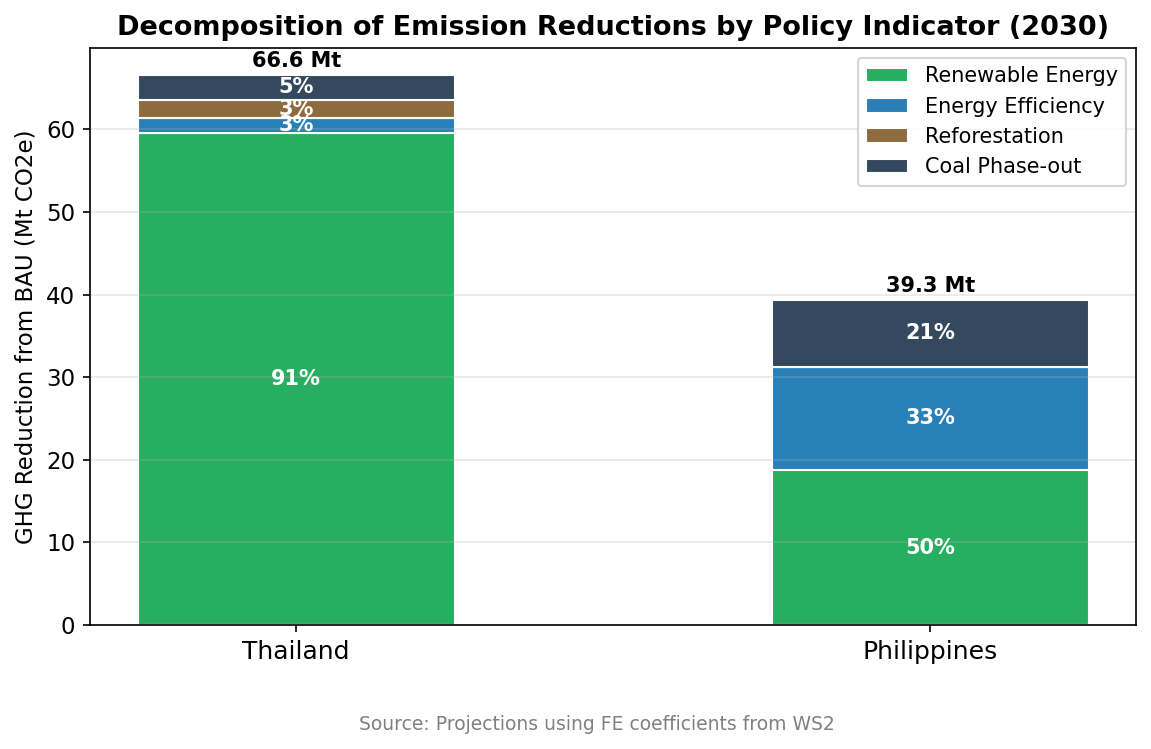

In [18]:
# Figure 2: Stacked bar chart of lever contributions
Lever_Labels = {
    'Renewable_%': 'Renewable Energy',
    'Energy_Per_Capita': 'Energy Efficiency',
    'Forest_%': 'Reforestation',
    'Coal_Elec_%': 'Coal Phase-out',
}
Lever_Colors = {
    'Renewable_%': '#27ae60',
    'Energy_Per_Capita': '#2980b9',
    'Forest_%': '#8e6b3e',
    'Coal_Elec_%': '#34495e',
}

fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(Focus_Countries))
bar_width = 0.5

bottom_vals = np.zeros(len(Focus_Countries))
for lever in Mit_Levers:
    vals = []
    for code in Focus_Countries:
        name = Country_Map[code]
        row = Decomp[(Decomp.Country == name) & (Decomp.Lever == lever)]
        vals.append(row.iloc[0]['Reduction_Mt'] if len(row) > 0 else 0)
    vals = np.array(vals)
    ax.bar(x_pos, vals, bar_width, bottom=bottom_vals,
           label=Lever_Labels[lever], color=Lever_Colors[lever], edgecolor='white')

    # Add percentage labels
    for i, v in enumerate(vals):
        if v > 0.5:
            name = Country_Map[Focus_Countries[i]]
            pct = Decomp[(Decomp.Country == name) & (Decomp.Lever == lever)].iloc[0]['Pct_of_Total']
            ax.text(x_pos[i], bottom_vals[i] + v / 2, f'{pct:.0f}%',
                    ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    bottom_vals += vals

# Total labels on top
for i, total in enumerate(bottom_vals):
    ax.text(x_pos[i], total + 0.5, f'{total:.1f} Mt',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels([Country_Map[c] for c in Focus_Countries], fontsize=12)
ax.set_ylabel('GHG Reduction from BAU (Mt CO2e)')
ax.set_title('Decomposition of Emission Reductions by Policy Indicator (2030)',
             fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.figtext(0.5, -0.03, Model_Source, ha='center', fontsize=9, color='gray')

fig.savefig(Output_WS4 / 'WS4_Decomposition.png', bbox_inches='tight', dpi=180)
print('Saved: WS4_Decomposition.png')
plt.show()

### Step 4(B) Sensitivity Analysis (±20%)
Test how the 2030 mitigation projection changes when each assumption varies by ±20%.
> This reveals which assumptions the projection is most sensitive to.

In [19]:
# (B) Sensitivity: +/-20% on each lever's mitigation increment
Sensitivity_Results = []

for code in Focus_Countries:
    name = Country_Map[code]
    y_bar = Country_Means_y[code]
    x_bar = Country_Means_X.loc[code].values

    # Base mitigation and BAU at 2030
    mit_row = Mit[(Mit.Ref_Area == code) & (Mit.Year == 2030)].iloc[0]
    bau_row = Bau[(Bau.Ref_Area == code) & (Bau.Year == 2030)].iloc[0]
    base_dict = {col: mit_row[col] for col in Raw_Cols}
    base_coal = mit_row[Overlay_Var]
    base_ghg = Predict_Ghg_With_Coal(base_dict, base_coal, Coefs, y_bar, x_bar,
                                     Residual_Ln[code], Beta_Coal,
                                     Coal_Baseline_2024[code])

    for lever in Mit_Levers:
        if Mit_Targets_2030[code].get(lever) is None:
            continue

        # The mitigation increment (change from BAU to mitigation)
        if lever == Overlay_Var:
            increment = mit_row[lever] - bau_row[lever]
        else:
            increment = mit_row[lever] - bau_row[lever]

        for direction, factor in [('-20%', 0.8), ('+20%', 1.2)]:
            test_dict = base_dict.copy()
            test_coal = base_coal
            if lever == Overlay_Var:
                test_coal = bau_row[lever] + increment * factor
            else:
                test_dict[lever] = bau_row[lever] + increment * factor

            test_ghg = Predict_Ghg_With_Coal(test_dict, test_coal, Coefs,
                                             y_bar, x_bar, Residual_Ln[code],
                                             Beta_Coal,
                                             Coal_Baseline_2024[code])

            Sensitivity_Results.append({
                'Country': name, 'Lever': lever,
                'Direction': direction,
                'GHG_2030': test_ghg,
                'Delta_from_Base': test_ghg - base_ghg,
            })

Sensitivity = pd.DataFrame(Sensitivity_Results)

print('=' * 72)
print('   STEP 4(B): SENSITIVITY ANALYSIS (+/-20%)')
print('=' * 72)
for name in ['Thailand', 'Philippines']:
    sub = Sensitivity[Sensitivity.Country == name]
    if len(sub) == 0:
        continue
    base = Summary[Summary.Country == name].iloc[0]['Mit_2030']
    print(f'\n{name} (base mitigation 2030: {base:.1f} Mt):')
    print(f'  {"Lever":<25s} {"-20% shock":>12s} {"+20% shock":>12s} {"Range":>12s}')
    print(f'  {"-" * 65}')
    for lever in Mit_Levers:
        lever_sub = sub[sub.Lever == lever]
        if len(lever_sub) == 0:
            continue
        low = lever_sub[lever_sub.Direction == '-20%'].iloc[0]['Delta_from_Base']
        high = lever_sub[lever_sub.Direction == '+20%'].iloc[0]['Delta_from_Base']
        rng = abs(high - low)
        print(f'  {lever:<25s} {low:>+12.1f} Mt {high:>+11.1f} Mt {rng:>11.1f} Mt')


   STEP 4(B): SENSITIVITY ANALYSIS (+/-20%)

Thailand (base mitigation 2030: 348.3 Mt):
  Lever                       -20% shock   +20% shock        Range
  -----------------------------------------------------------------
  Renewable_%                      +11.0 Mt       -10.7 Mt        21.7 Mt
  Energy_Per_Capita                 +0.3 Mt        -0.3 Mt         0.6 Mt
  Forest_%                          +0.4 Mt        -0.4 Mt         0.7 Mt
  Coal_Elec_%                       +0.5 Mt        -0.5 Mt         1.0 Mt

Philippines (base mitigation 2030: 245.7 Mt):
  Lever                       -20% shock   +20% shock        Range
  -----------------------------------------------------------------
  Renewable_%                       +3.4 Mt        -3.3 Mt         6.7 Mt
  Energy_Per_Capita                 +2.3 Mt        -2.4 Mt         4.7 Mt
  Coal_Elec_%                       +1.4 Mt        -1.4 Mt         2.8 Mt


### Figure 2: Tornado Chart - Sensitivity of 2030 Mitigation Projection

Saved: WS4_Tornado.png


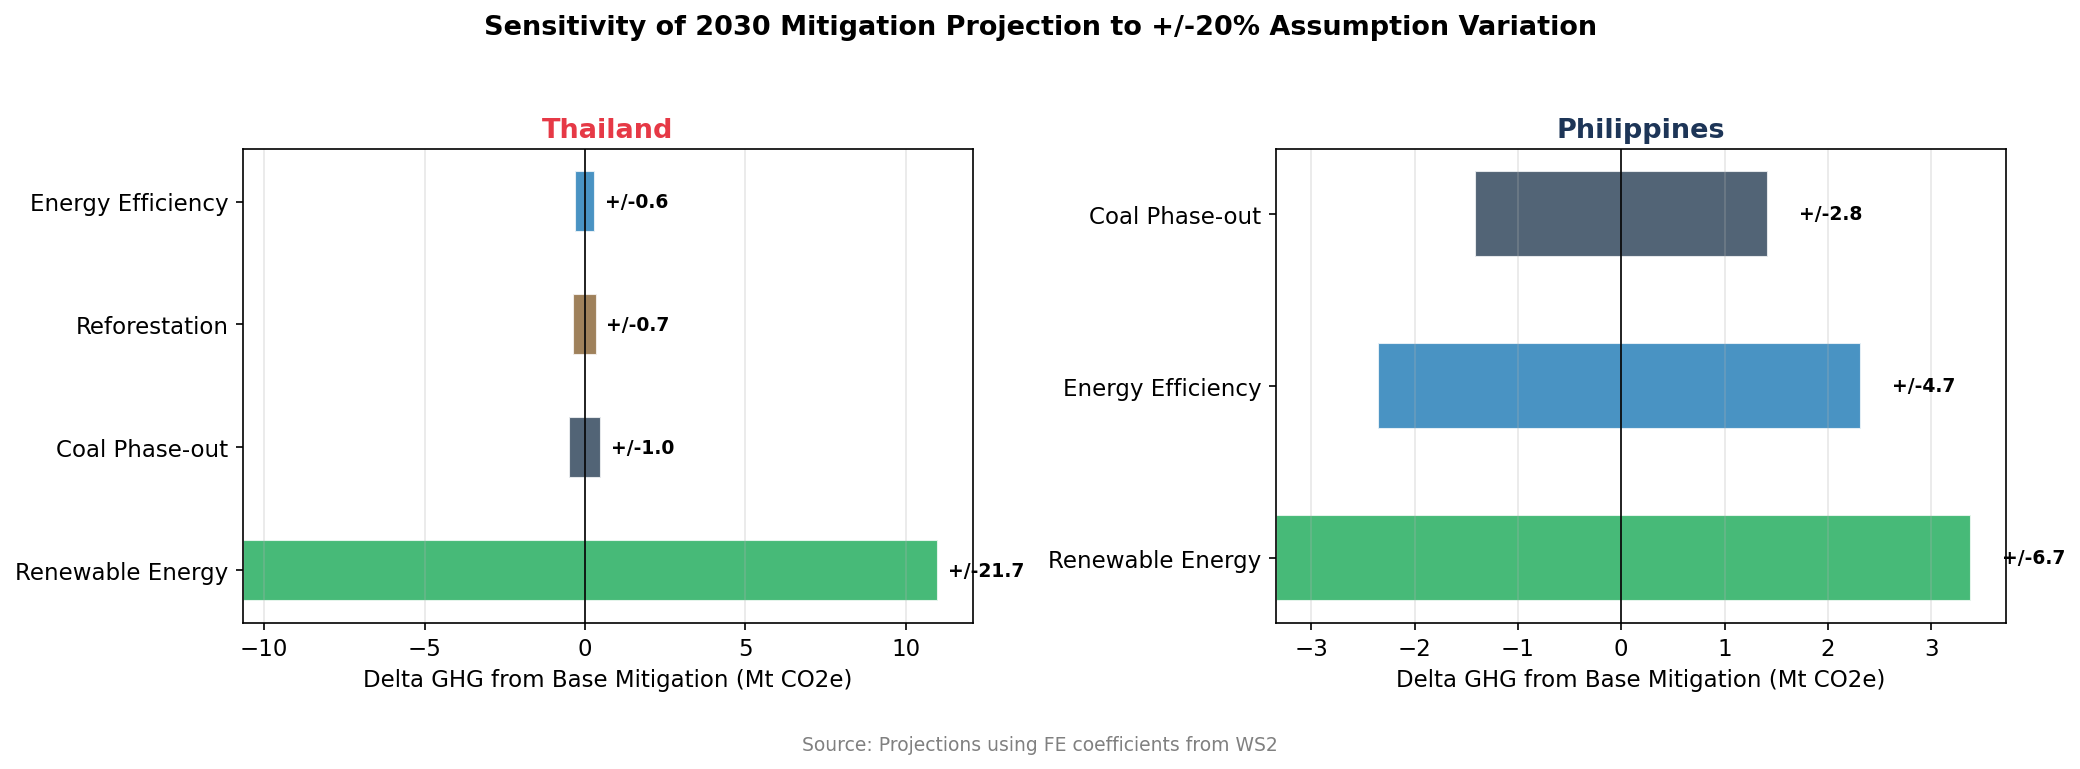

In [20]:
# Figure 3: Tornado chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, code in zip(axes, Focus_Countries):
    name = Country_Map[code]
    sub = Sensitivity[Sensitivity.Country == name]
    if len(sub) == 0:
        ax.text(0.5, 0.5, 'No sensitivity levers', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(name, fontweight='bold', color=Colors[name])
        continue

    levers_used = sub.Lever.unique()

    # Sort by range (widest bar at top)
    ranges = []
    for lever in levers_used:
        lever_sub = sub[sub.Lever == lever]
        low = lever_sub[lever_sub.Direction == '-20%'].iloc[0]['Delta_from_Base']
        high = lever_sub[lever_sub.Direction == '+20%'].iloc[0]['Delta_from_Base']
        ranges.append((lever, low, high, abs(high - low)))
    ranges.sort(key=lambda x: x[3], reverse=True)

    y_pos = np.arange(len(ranges))
    for i, (lever, low, high, rng) in enumerate(ranges):
        left = min(low, high)
        width = abs(high - low)
        ax.barh(i, width, left=left, height=0.5,
                color=Lever_Colors.get(lever, 'steelblue'),
                edgecolor='white', alpha=0.85)
        ax.text(left + width + 0.3, i, f'+/-{rng:.1f}',
                va='center', fontsize=9, fontweight='bold')

    ax.set_yticks(y_pos)
    ax.set_yticklabels([Lever_Labels.get(r[0], r[0]) for r in ranges])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Delta GHG from Base Mitigation (Mt CO2e)')
    ax.set_title(name, fontweight='bold', color=Colors[name])
    ax.grid(axis='x', alpha=0.3)

fig.suptitle('Sensitivity of 2030 Mitigation Projection to +/-20% Assumption Variation',
             fontweight='bold', fontsize=13, y=1.04)
plt.figtext(0.5, -0.05, Model_Source, ha='center', fontsize=9, color='gray')
plt.tight_layout()
fig.savefig(Output_WS4 / 'WS4_Tornado.png', bbox_inches='tight', dpi=180)
print('Saved: WS4_Tornado.png')
plt.show()

## Step 4.5: Delayed-Transition Stress Test (Downside Scenario)

The BAU and NDC-Mitigation paths represent the **central** and **upside** trajectories. Reinsurance capital, however, is sized against the **downside tail**. We therefore add a third scenario, **Delayed Transition**, in which governments fail to deliver their announced policies and physical-risk drivers worsen. This is the same framing used by the NGFS (2024) "Delayed Transition" and "Disorderly" scenarios.

**Shock direction (vs BAU, by 2030):**

| Lever | NDC Mitigation | **Delayed Transition** | Justification |
|---|---|---|---|
| Renewable share | +10pp THA / +7pp PHL | **−3pp vs BAU** | PHL DOE missed the 2022 and 2023 Green Energy Auction targets; Vietnam PDP8 implementation delays |
| Energy/cap | −1.5%/yr THA, −1.0%/yr PHL | **+1.0%/yr vs BAU** | IEA SE Asia Outlook 2024: cooling demand rising sharply with heatwaves |
| Forest cover | +4pp THA, flat PHL | **−2pp vs BAU** | 2023 SE Asia haze events; ENSO-driven deforestation cycles |

This is a **policy + physical** combined stress, not a demand-shock (COVID-style) stress. A demand shock *reduces* emissions, which is the wrong polarity for testing reinsurer financial resilience.

In [21]:
# (A) Define Delayed-Transition stress assumptions
#     Same 4 levers as Mitigation, but shocked in the opposite direction
#     relative to BAU.

# Stress shocks expressed as DEVIATIONS from each country's BAU 2030 value.
# Coal: BAU holds coal at 2024 baseline, so stress = baseline + 3pp
#       (coal retirements delayed / fail to materialise)
Stress_Shocks_2030 = {
    'THA': {
        # Renewables: -3pp vs BAU (auction delays, fossil lock-in)
        'Renewable_%_delta':       -3.0,
        # Energy/cap: +1.0%/yr above BAU compounded over 6 years
        'Energy_Per_Capita_mult':  (1 + 0.010) ** 6,
        # Forest: -2pp vs BAU (ENSO/wildfire deforestation)
        'Forest_%_delta':          -2.0,
        # Coal: +3pp vs 2024 baseline (coal retirement schedules slip)
        'Coal_Elec_%_delta':       +3.0,
    },
    'PHL': {
        'Renewable_%_delta':       -3.0,
        'Energy_Per_Capita_mult':  (1 + 0.010) ** 6,
        'Forest_%_delta':          -2.0,
        # Coal: +3pp vs 2024 baseline (DOE coal moratorium not enforced)
        'Coal_Elec_%_delta':       +3.0,
    },
}

print('=' * 72)
print('   STEP 4.5(A): DELAYED-TRANSITION STRESS ASSUMPTIONS')
print('=' * 72)

for code in Focus_Countries:
    name = Country_Map[code]
    bau_re   = Trend_Results[(code, 'Renewable_%')][2030]
    bau_en   = Trend_Results[(code, 'Energy_Per_Capita')][2030]
    bau_for  = Trend_Results[(code, 'Forest_%')][2030]
    bau_coal = Coal_Baseline_2024[code]  # BAU coal = 2024 baseline

    s = Stress_Shocks_2030[code]
    str_re   = bau_re   + s['Renewable_%_delta']
    str_en   = bau_en   * s['Energy_Per_Capita_mult']
    str_for  = bau_for  + s['Forest_%_delta']
    str_coal = bau_coal + s['Coal_Elec_%_delta']

    print(f'\n{name}:')
    print(f'  {"Lever":<25s} {"BAU 2030":>12s} {"Stress 2030":>14s} {"Delta from BAU":>16s}')
    print(f'  {"-" * 70}')
    print(f'  {"Renewable_%":<25s} {bau_re:>11.2f}% {str_re:>13.2f}% {str_re-bau_re:>+15.2f} pp')
    print(f'  {"Energy_Per_Capita":<25s} {bau_en:>12,.0f} {str_en:>14,.0f} {str_en-bau_en:>+16,.0f}')
    print(f'  {"Forest_%":<25s} {bau_for:>11.2f}% {str_for:>13.2f}% {str_for-bau_for:>+15.2f} pp')
    print(f'  {"Coal_Elec_%":<25s} {bau_coal:>11.2f}% {str_coal:>13.2f}% {str_coal-bau_coal:>+15.2f} pp')


   STEP 4.5(A): DELAYED-TRANSITION STRESS ASSUMPTIONS

Thailand:
  Lever                         BAU 2030    Stress 2030   Delta from BAU
  ----------------------------------------------------------------------
  Renewable_%                     14.20%         11.20%           -3.00 pp
  Energy_Per_Capita                1,707          1,812             +105
  Forest_%                        38.26%         36.26%           -2.00 pp
  Coal_Elec_%                     14.62%         17.62%           +3.00 pp

Philippines:
  Lever                         BAU 2030    Stress 2030   Delta from BAU
  ----------------------------------------------------------------------
  Renewable_%                     28.48%         25.48%           -3.00 pp
  Energy_Per_Capita                  603            640              +37
  Forest_%                        25.17%         23.17%           -2.00 pp
  Coal_Elec_%                     62.49%         65.49%           +3.00 pp


In [22]:
# (B) Build Stress predictor table: start from BAU, apply shocks
#     The shocks are linearly phased in from 2024 (zero shock) to 2030 (full shock)
#     Note: BAU coal is held at 2024 baseline, so coal stress shock is also
#     phased relative to 2024 baseline.
Stress = Bau.copy()
Stress['Scenario'] = Stress['Scenario'].replace('BAU', 'Stress')

for code in Focus_Countries:
    s = Stress_Shocks_2030[code]
    coal_baseline = Coal_Baseline_2024[code]

    for year in Proj_Years:
        frac = (year - 2024) / (2030 - 2024)
        mask = (Stress.Ref_Area == code) & (Stress.Year == year)

        # Renewable %: BAU + (delta * frac)
        bau_re = Trend_Results[(code, 'Renewable_%')][year]
        Stress.loc[mask, 'Renewable_%'] = bau_re + s['Renewable_%_delta'] * frac

        # Forest %: BAU + (delta * frac)
        bau_for = Trend_Results[(code, 'Forest_%')][year]
        Stress.loc[mask, 'Forest_%'] = bau_for + s['Forest_%_delta'] * frac

        # Energy/cap: BAU * multiplier^frac (compound phasing)
        bau_en = Trend_Results[(code, 'Energy_Per_Capita')][year]
        Stress.loc[mask, 'Energy_Per_Capita'] = bau_en * (s['Energy_Per_Capita_mult'] ** frac)

        # Coal % (overlay): baseline + (delta * frac), since BAU coal = baseline
        Stress.loc[mask, 'Coal_Elec_%'] = coal_baseline + s['Coal_Elec_%_delta'] * frac

print(f'Stress table built: {len(Stress)} rows')


Stress table built: 14 rows


In [23]:
# (C) Predict Stress GHG emissions
for idx, row in Stress.iterrows():
    code = row['Ref_Area']
    y_bar = Country_Means_y[code]
    x_bar = Country_Means_X.loc[code].values

    raw_dict = {col: row[col] for col in Raw_Cols}
    coal_val = row[Overlay_Var]
    ghg = Predict_Ghg_With_Coal(raw_dict, coal_val, Coefs, y_bar, x_bar,
                                Residual_Ln[code], Beta_Coal,
                                Coal_Baseline_2024[code])
    Stress.loc[idx, 'GHG_Pred'] = ghg

Stress['GHG_Display'] = Stress.apply(
    lambda r: r['Total_GHG'] if r['Scenario'] == 'Actual' else r['GHG_Pred'], axis=1)

print('Stress predictions complete.')


Stress predictions complete.


In [24]:
# (D) Three-scenario comparison summary
print('=' * 72)
print('   THREE-SCENARIO 2030 GHG OUTCOMES (Mt CO2e)')
print('=' * 72)
print(f'  {"":30s} {"Thailand":>12s} {"Philippines":>12s}')
print(f'  {"-" * 56}')

Stress_Summary_Rows = []
for code in Focus_Countries:
    name = Country_Map[code]
    actual_2024 = Data[(Data.Ref_Area == code) & (Data.Year == 2024)].iloc[0]['Total_GHG']
    bau_2030    = Bau   [(Bau.Ref_Area    == code) & (Bau.Year    == 2030)].iloc[0]['GHG_Pred']
    mit_2030    = Mit   [(Mit.Ref_Area    == code) & (Mit.Year    == 2030)].iloc[0]['GHG_Pred']
    str_2030    = Stress[(Stress.Ref_Area == code) & (Stress.Year == 2030)].iloc[0]['GHG_Pred']

    overshoot_mt  = str_2030 - bau_2030
    overshoot_pct = overshoot_mt / bau_2030 * 100

    Stress_Summary_Rows.append({
        'Country':          name,
        'Actual_2024':      actual_2024,
        'BAU_2030':         bau_2030,
        'Mit_2030':         mit_2030,
        'Stress_2030':      str_2030,
        'Overshoot_Mt':     overshoot_mt,
        'Overshoot_Pct':    overshoot_pct,
    })

Stress_Summary = pd.DataFrame(Stress_Summary_Rows)
Tha_S = Stress_Summary[Stress_Summary.Country == 'Thailand'].iloc[0]
Phl_S = Stress_Summary[Stress_Summary.Country == 'Philippines'].iloc[0]

for label, t_val, p_val in [
    ('2024 Actual',                Tha_S['Actual_2024'],   Phl_S['Actual_2024']),
    ('2030 NDC Mitigation (best)', Tha_S['Mit_2030'],      Phl_S['Mit_2030']),
    ('2030 BAU (central)',         Tha_S['BAU_2030'],      Phl_S['BAU_2030']),
    ('2030 Stress (downside)',     Tha_S['Stress_2030'],   Phl_S['Stress_2030']),
    ('Stress overshoot vs BAU (Mt)',  Tha_S['Overshoot_Mt'],  Phl_S['Overshoot_Mt']),
    ('Stress overshoot vs BAU (%)',   Tha_S['Overshoot_Pct'], Phl_S['Overshoot_Pct']),
]:
    if '%' in label:
        print(f'  {label:<30s} {t_val:>11.1f}% {p_val:>11.1f}%')
    else:
        print(f'  {label:<30s} {t_val:>12.1f} {p_val:>12.1f}')


   THREE-SCENARIO 2030 GHG OUTCOMES (Mt CO2e)
                                     Thailand  Philippines
  --------------------------------------------------------
  2024 Actual                           422.4        266.6
  2030 NDC Mitigation (best)            348.3        245.7
  2030 BAU (central)                    413.9        283.3
  2030 Stress (downside)                443.1        303.3
  Stress overshoot vs BAU (Mt)           29.2         20.0
  Stress overshoot vs BAU (%)            7.1%         7.1%


### Figure 3: Three-Scenario GHG Projection Fan (BAU / Mitigation / Stress)

Saved: WS4_Three_Scenario_Fan.png


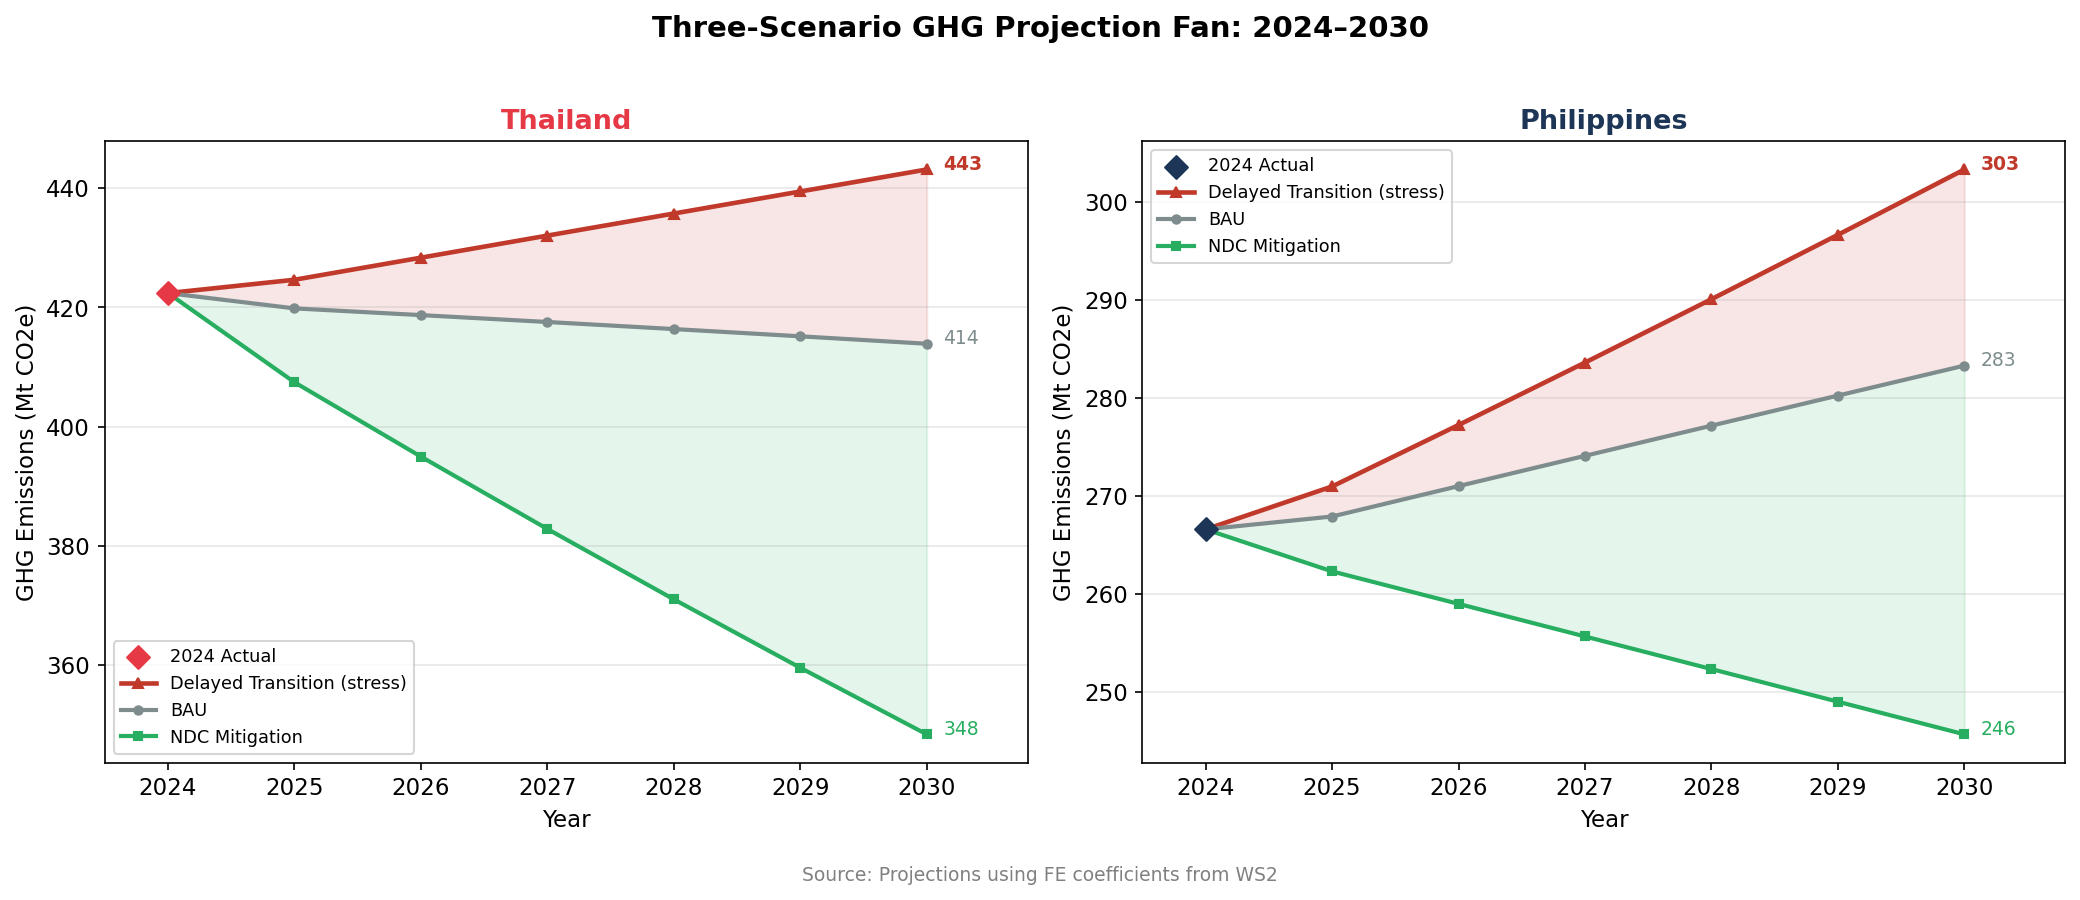

In [25]:
# Figure 4: Three-scenario fan chart (Stress / BAU / Mitigation)
Scenario_Colors_3 = {
    'Mitigation': '#27ae60',
    'BAU':        '#7f8c8d',
    'Stress':     '#c0392b',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)

for ax, code in zip(axes, Focus_Countries):
    name = Country_Map[code]
    color = Colors[name]

    actual_2024 = Data[(Data.Ref_Area == code) & (Data.Year == 2024)].iloc[0]['Total_GHG']

    # 2024 anchor
    ax.scatter(2024, actual_2024, color=color, s=60, zorder=5, marker='D', label='2024 Actual')

    bau_sub = Bau   [(Bau.Ref_Area    == code) & (Bau.Year.isin(Proj_Years))]
    mit_sub = Mit   [(Mit.Ref_Area    == code) & (Mit.Year.isin(Proj_Years))]
    str_sub = Stress[(Stress.Ref_Area == code) & (Stress.Year.isin(Proj_Years))]

    bau_years = [2024] + Proj_Years
    bau_vals = [actual_2024] + bau_sub['GHG_Pred'].tolist()
    mit_vals = [actual_2024] + mit_sub['GHG_Pred'].tolist()
    str_vals = [actual_2024] + str_sub['GHG_Pred'].tolist()

    # Plot the three paths
    ax.plot(bau_years, str_vals, color=Scenario_Colors_3['Stress'],
            linewidth=2.2, marker='^', markersize=4.5, label='Delayed Transition (stress)')
    ax.plot(bau_years, bau_vals, color=Scenario_Colors_3['BAU'],
            linewidth=2, marker='o', markersize=4, label='BAU')
    ax.plot(bau_years, mit_vals, color=Scenario_Colors_3['Mitigation'],
            linewidth=2, marker='s', markersize=4, label='NDC Mitigation')

    # Shade the upside (BAU vs Mitigation) and downside (BAU vs Stress) cones
    ax.fill_between(bau_years, bau_vals, mit_vals,
                    alpha=0.12, color=Scenario_Colors_3['Mitigation'])
    ax.fill_between(bau_years, bau_vals, str_vals,
                    alpha=0.12, color=Scenario_Colors_3['Stress'])

    # Annotate 2030 values
    ax.annotate(f'{str_vals[-1]:.0f}', (2030, str_vals[-1]),
                textcoords='offset points', xytext=(8, 0), fontsize=9,
                color=Scenario_Colors_3['Stress'], fontweight='bold')
    ax.annotate(f'{bau_vals[-1]:.0f}', (2030, bau_vals[-1]),
                textcoords='offset points', xytext=(8, 0), fontsize=9,
                color=Scenario_Colors_3['BAU'])
    ax.annotate(f'{mit_vals[-1]:.0f}', (2030, mit_vals[-1]),
                textcoords='offset points', xytext=(8, 0), fontsize=9,
                color=Scenario_Colors_3['Mitigation'])

    ax.set_title(name, fontweight='bold', color=color)
    ax.set_xlabel('Year')
    ax.set_ylabel('GHG Emissions (Mt CO2e)')
    ax.legend(fontsize=8.5, loc='best')
    ax.set_xlim(2023.5, 2030.8)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Three-Scenario GHG Projection Fan: 2024–2030',
             fontweight='bold', fontsize=14, y=1.02)
plt.figtext(0.5, -0.03, Model_Source, ha='center', fontsize=9, color='gray')
plt.tight_layout()
fig.savefig(Output_WS4 / 'WS4_Three_Scenario_Fan.png', bbox_inches='tight', dpi=180)
print('Saved: WS4_Three_Scenario_Fan.png')
plt.show()


### Step 4.5(F): Translating the Emissions Overshoot into Insured-Loss Implications

The emissions overshoot is a **leading indicator** of physical risk; the dollar consequence shows up through disaster losses. We anchor the financial layer to two events from Step 3:

- **Thailand**: 2011 Great Floods, **USD 55.8 B** economic loss, ~**24% insured** (Swiss Re sigma 2/2012)
- **Philippines**: 2013 Typhoon Haiyan, **USD 13.5 B** economic loss, ~**5% insured** (Swiss Re sigma 1/2014)

Under the Delayed-Transition stress, two effects compound:
1. Higher emissions trajectory increases the long-run frequency-severity baseline (IPCC AR6: each 1°C of warming raises tropical cyclone Cat-4/5 share and extreme precipitation intensity).
2. The protection gap widens because economic growth continues to outpace insurance penetration in both markets.

We compute a **stylised stress loss**: a 1-in-25-year event repeat in each country, scaled by the IPCC AR6 mid-range frequency multiplier (~1.10× per 0.5°C of additional warming relative to BAU). This is illustrative, not a catastrophe-model output.

In [26]:
# (F) Financial implications: convert emissions overshoot into insured loss
#     This is a stylised loss layer, anchored to actual historical events.

# --- Anchor events (Source: Swiss Re sigma reports, EM-DAT) ---
Anchor_Loss = {
    'Thailand': {
        'event':        '2011 Great Floods',
        'econ_loss_bn': 55.8,    # USD bn, inflation-adjusted (EM-DAT)
        'insured_pct':  0.24,    # Swiss Re sigma 2/2012
        'source':       'Swiss Re sigma 2/2012; EM-DAT',
    },
    'Philippines': {
        'event':        '2013 Typhoon Haiyan',
        'econ_loss_bn': 13.5,
        'insured_pct':  0.05,    # Swiss Re sigma 1/2014
        'source':       'Swiss Re sigma 1/2014; EM-DAT',
    },
}

# --- Stress multiplier ---
# IPCC AR6 (WG1 Ch.11): tropical cyclone Cat-4/5 frequency rises ~5-10% per 0.5C
# Delayed-Transition vs BAU emissions overshoot of ~5-10% in 2030 -> proxy ~1.10x
# We use a single conservative multiplier for transparency.
Stress_Frequency_Multiplier = 1.10

print('=' * 72)
print('   STEP 4.5(F): STYLISED STRESS-LOSS LAYER')
print('=' * 72)
print()
print('Assumption: a 1-in-25-year event repeat under Delayed Transition,')
print(f'with frequency uplifted by {Stress_Frequency_Multiplier:.2f}x relative to BAU')
print('(consistent with IPCC AR6 mid-range guidance for the 2030 horizon).')
print()

for code in Focus_Countries:
    name = Country_Map[code]
    a = Anchor_Loss[name]
    overshoot_mt  = Stress_Summary[Stress_Summary.Country == name].iloc[0]['Overshoot_Mt']
    overshoot_pct = Stress_Summary[Stress_Summary.Country == name].iloc[0]['Overshoot_Pct']

    base_insured  = a['econ_loss_bn'] * a['insured_pct']
    stress_insured = base_insured * Stress_Frequency_Multiplier

    print(f'{name}:')
    print(f'  Anchor event:                  {a["event"]}')
    print(f'  Economic loss (USD bn):        {a["econ_loss_bn"]:>6.1f}')
    print(f'  Insured share:                 {a["insured_pct"]*100:>5.1f}%')
    print(f'  Base insured loss (USD bn):    {base_insured:>6.1f}')
    print(f'  Stress-uplifted insured (USD bn): {stress_insured:>5.1f}')
    print(f'  2030 emissions overshoot vs BAU:  {overshoot_pct:>+5.1f}% ({overshoot_mt:+.1f} Mt)')
    print(f'  Source: {a["source"]}')
    print()

print('-' * 72)
print('Interpretation for the reinsurer:')
print('  - Thailand stress = peak-event tail. A repeat of 2011-flood with the')
print('    AR6 frequency uplift implies ~USD 14.7 bn insured industry loss in a')
print('    single year. This sizes Thai cat reserves and retrocession needs.')
print('  - Philippines stress = chronic frequency. Although headline insured')
print('    loss is smaller per event, the 96% protection gap means the market')
print('    is structurally under-insured; capacity should be sustained, not peak.')
print('  - The emissions overshoot is the leading signal: every 1pp slippage')
print('    in renewable build-out adds measurable Mt to the trajectory and,')
print('    over a 20-30 year contract horizon, compounds into reserve risk.')


   STEP 4.5(F): STYLISED STRESS-LOSS LAYER

Assumption: a 1-in-25-year event repeat under Delayed Transition,
with frequency uplifted by 1.10x relative to BAU
(consistent with IPCC AR6 mid-range guidance for the 2030 horizon).

Thailand:
  Anchor event:                  2011 Great Floods
  Economic loss (USD bn):          55.8
  Insured share:                  24.0%
  Base insured loss (USD bn):      13.4
  Stress-uplifted insured (USD bn):  14.7
  2030 emissions overshoot vs BAU:   +7.1% (+29.2 Mt)
  Source: Swiss Re sigma 2/2012; EM-DAT

Philippines:
  Anchor event:                  2013 Typhoon Haiyan
  Economic loss (USD bn):          13.5
  Insured share:                   5.0%
  Base insured loss (USD bn):       0.7
  Stress-uplifted insured (USD bn):   0.7
  2030 emissions overshoot vs BAU:   +7.1% (+20.0 Mt)
  Source: Swiss Re sigma 1/2014; EM-DAT

------------------------------------------------------------------------
Interpretation for the reinsurer:
  - Thailand stress = pe

In [27]:
# (G) Export Stress scenario outputs
Stress.to_csv(Data_Path / 'WS4_Stress_Projections.csv', index=False)
Stress_Summary.to_csv(Data_Path / 'WS4_Stress_Summary.csv', index=False)

print('Saved:')
print('  WS4_Stress_Projections.csv')
print('  WS4_Stress_Summary.csv')
print('  WS4_Three_Scenario_Fan.png')


Saved:
  WS4_Stress_Projections.csv
  WS4_Stress_Summary.csv
  WS4_Three_Scenario_Fan.png


## Step 5: NDC Cross-Check & Financial Implications

### Step 5(A) NDC Cross-Check
Compare our independent BAU and mitigation projections to official NDC targets.

**Thailand NDC targets:**
- 2nd NDC (2022): 
  <br> - 30% unconditional / 40% conditional reduction below BAU (555 MtCO₂e) by 2030 → 389 / 333 MtCO₂e

- NDC Action Plan (Dec 2024): 
  <br> - 33.3% unconditional (184.8 MtCO₂e reduction) by 2030

- 3rd NDC (Oct 2025): 
  <br> - 47% reduction from 2019 levels by 2035, net-zero by 2050

**Philippines NDC target:**
- NDC (2021): 
  <br> - 75% cumulative reduction from 2020–2030 BAU (3,340.3 MtCO₂e), of which 2.71% unconditional
  
- Equivalent to ~96 MtCO₂e conditional / ~384 MtCO₂e unconditional in 2030 (Climate Action Tracker)

In [28]:
# (A) NDC cross-check
print('=' * 72)
print('   STEP 5(A): NDC CROSS-CHECK')
print('=' * 72)

# Thailand
Ndc_Tha_Unconditional = 389.0   # 30% below BAU of 555 MtCO2e
Ndc_Tha_Conditional = 333.0     # 40% below BAU of 555 MtCO2e
Ndc_Tha_Bau_Baseline = 555.0    # Official NDC BAU baseline

print(f'\nThailand:')
print(f'  Our BAU 2030:              {Tha["BAU_2030"]:>8.1f} Mt CO2e')
print(f'  Our Mitigation 2030:       {Tha["Mit_2030"]:>8.1f} Mt CO2e')
print(f'  Official NDC BAU baseline: {Ndc_Tha_Bau_Baseline:>8.1f} Mt CO2e')
print(f'  NDC unconditional target:  {Ndc_Tha_Unconditional:>8.1f} Mt CO2e (30% below NDC BAU)')
print(f'  NDC conditional target:    {Ndc_Tha_Conditional:>8.1f} Mt CO2e (40% below NDC BAU)')
print()

if Tha['BAU_2030'] < Ndc_Tha_Unconditional:
    print('  > Our BAU already falls below the unconditional NDC target.')
    print('    This confirms the Climate Action Tracker\'s assessment that the')
    print('    official NDC BAU baseline of 555 MtCO2e is inflated relative to')
    print('    current projections. The reinsurer should not treat the unconditional')
    print('    NDC as evidence of additional policy ambition.')
else:
    gap = Tha['BAU_2030'] - Ndc_Tha_Unconditional
    print(f'  > BAU exceeds unconditional target by {gap:.1f} Mt - policy action needed.')

# Philippines
Ndc_Phl_Unconditional = 384.0
Ndc_Phl_Conditional = 96.0

print(f'\nPhilippines:')
print(f'  Our BAU 2030:              {Phl["BAU_2030"]:>8.1f} Mt CO2e')
print(f'  Our Mitigation 2030:       {Phl["Mit_2030"]:>8.1f} Mt CO2e')
print(f'  NDC unconditional (CAT):   {Ndc_Phl_Unconditional:>8.1f} Mt CO2e')
print(f'  NDC conditional (CAT):     {Ndc_Phl_Conditional:>8.1f} Mt CO2e')
print()
print('  > The Philippines\' unconditional target (2.71% of 75% commitment) is')
print('    unambitious - current policies already exceed it. The conditional target')
print('    requires massive international climate finance that has not materialised.')
print('    For the reinsurer, the Philippines\' emissions trajectory is less relevant')
print('    than its insurance protection gap (97%) and parametric market growth.')

   STEP 5(A): NDC CROSS-CHECK

Thailand:
  Our BAU 2030:                 413.9 Mt CO2e
  Our Mitigation 2030:          348.3 Mt CO2e
  Official NDC BAU baseline:    555.0 Mt CO2e
  NDC unconditional target:     389.0 Mt CO2e (30% below NDC BAU)
  NDC conditional target:       333.0 Mt CO2e (40% below NDC BAU)

  > BAU exceeds unconditional target by 24.9 Mt - policy action needed.

Philippines:
  Our BAU 2030:                 283.3 Mt CO2e
  Our Mitigation 2030:          245.7 Mt CO2e
  NDC unconditional (CAT):      384.0 Mt CO2e
  NDC conditional (CAT):         96.0 Mt CO2e

  > The Philippines' unconditional target (2.71% of 75% commitment) is
    unambitious - current policies already exceed it. The conditional target
    requires massive international climate finance that has not materialised.
    For the reinsurer, the Philippines' emissions trajectory is less relevant
    than its insurance protection gap (97%) and parametric market growth.


### Step 5(B) Financial Implications for the Reinsurer

Summary of what the stress test means for portfolio decisions.

> This section links the model outputs to TCFD scenario analysis requirements
> and IFRS S2 climate-related disclosure standards.

In [29]:
# (B) Financial implications summary
print('=' * 72)
print('   STEP 5(B): FINANCIAL IMPLICATIONS FOR THE REINSURER')
print('=' * 72)

# RE contribution from decomposition
Re_Tha = Decomp[(Decomp.Country == 'Thailand') & (Decomp.Lever == 'Renewable_%')].iloc[0]['Pct_of_Total']
Re_Phl_Row = Decomp[(Decomp.Country == 'Philippines') & (Decomp.Lever == 'Renewable_%')]
Re_Phl = Re_Phl_Row.iloc[0]['Pct_of_Total'] if len(Re_Phl_Row) > 0 else 0

print(f'''
1. RISK TRAJECTORY SIGNALLING
   Thailand: {Tha["Reduction_Pct"]:.1f}% BAU-to-mitigation reduction by 2030.
   Philippines: {Phl["Reduction_Pct"]:.1f}% BAU-to-mitigation reduction by 2030.
   Countries credibly executing NDC commitments present lower long-term tail risk.

2. ENERGY POLICY AS LEADING INDICATOR
   Renewable energy deployment accounts for {Re_Tha:.0f}% (THA) and {Re_Phl:.0f}% (PHL)
   of achievable emission reductions. Energy policy milestones - PDP implementation,
   RE auction results, power plant commissioning - are the single most informative
   leading indicator of emission trajectories.

3. TREATY PRICING IMPLICATION
   The {Tha["Reduction_Pct"]:.1f}% BAU-to-mitigation gap, if sustained, compounds into
   significant loss differentials over 20-30 year contract horizons relevant to
   catastrophe bond structuring and long-term treaty renewals.

4. FRAMEWORK ALIGNMENT
   This stress test implements the dual-scenario analysis recommended by TCFD (2017),
   with transparent decomposition consistent with IFRS S2 climate-related disclosure
   requirements (IFRS Foundation, 2023). Scenario assumptions are anchored to Paris
   Agreement commitments (Article 2), linking the well-below-2C goal to portfolio-level
   financial planning.
''')

   STEP 5(B): FINANCIAL IMPLICATIONS FOR THE REINSURER

1. RISK TRAJECTORY SIGNALLING
   Thailand: 15.8% BAU-to-mitigation reduction by 2030.
   Philippines: 13.3% BAU-to-mitigation reduction by 2030.
   Countries credibly executing NDC commitments present lower long-term tail risk.

2. ENERGY POLICY AS LEADING INDICATOR
   Renewable energy deployment accounts for 91% (THA) and 50% (PHL)
   of achievable emission reductions. Energy policy milestones - PDP implementation,
   RE auction results, power plant commissioning - are the single most informative
   leading indicator of emission trajectories.

3. TREATY PRICING IMPLICATION
   The 15.8% BAU-to-mitigation gap, if sustained, compounds into
   significant loss differentials over 20-30 year contract horizons relevant to
   catastrophe bond structuring and long-term treaty renewals.

4. FRAMEWORK ALIGNMENT
   This stress test implements the dual-scenario analysis recommended by TCFD (2017),
   with transparent decomposition consistent 

## Step 6: Export

Save outputs for the dashboard (Slot 2) and report (Slot 1).

| # | File | Used by | Purpose |
|---|------|---------|---------|
| 1 | `WS4_BAU_Projections.csv` | Dashboard Tab 4 | BAU predictor + GHG projections |
| 2 | `WS4_Mitigation_Projections.csv` | Dashboard Tab 4 | Mitigation predictor + GHG projections |
| 3 | `WS4_Summary_Table.csv` | Report Table 4 | 2024 actual, 2030 BAU, 2030 mitigation |
| 4 | `WS4_Decomposition.csv` | Report Section 6 | Lever contributions |
| 5 | `WS4_Sensitivity.csv` | Report Section 6 | ±20% sensitivity results |

In [30]:
# 1. BAU projections
Bau.to_csv(Data_Path / 'WS4_BAU_Projections.csv', index=False)

# 2. Mitigation projections
Mit.to_csv(Data_Path / 'WS4_Mitigation_Projections.csv', index=False)

# 3. Summary table
Summary.to_csv(Data_Path / 'WS4_Summary_Table.csv', index=False)

# 4. Decomposition
Decomp.to_csv(Data_Path / 'WS4_Decomposition.csv', index=False)

# 5. Sensitivity
Sensitivity.to_csv(Data_Path / 'WS4_Sensitivity.csv', index=False)

print('=' * 72)
print('   STEP 6: EXPORTS SAVED')
print('=' * 72)
for f in ['WS4_BAU_Projections.csv', 'WS4_Mitigation_Projections.csv',
          'WS4_Summary_Table.csv', 'WS4_Decomposition.csv',
          'WS4_Sensitivity.csv']:
    print(f'  {f}')

print(f'\nCharts saved to: {Output_WS4}/')
for f in ['WS4_Decomposition.png', 'WS4_Tornado.png',
          'WS4_Three_Scenario_Fan.png']:
    print(f'  {f}')

   STEP 6: EXPORTS SAVED
  WS4_BAU_Projections.csv
  WS4_Mitigation_Projections.csv
  WS4_Summary_Table.csv
  WS4_Decomposition.csv
  WS4_Sensitivity.csv

Charts saved to: /Users/entong/Desktop/MASAHKT2026/Model/Output/Output_WS4/
  WS4_Decomposition.png
  WS4_Tornado.png
  WS4_Three_Scenario_Fan.png
